Epoch 1/5 Train Loss: 0.9784, Train Acc: 75.16% Val Loss: 0.4351, Val Acc: 87.10%
Epoch 2/5 Train Loss: 0.3734, Train Acc: 89.15% Val Loss: 0.3238, Val Acc: 90.61%
Epoch 3/5 Train Loss: 0.3153, Train Acc: 90.81% Val Loss: 0.2902, Val Acc: 91.52%
Epoch 4/5 Train Loss: 0.2831, Train Acc: 91.65% Val Loss: 0.2959, Val Acc: 91.11%
Epoch 5/5 Train Loss: 0.2585, Train Acc: 92.45% Val Loss: 0.2444, Val Acc: 92.80%
Epoch 1/5 Train Loss: 0.9875, Train Acc: 74.61% Val Loss: 0.4199, Val Acc: 88.20%
Epoch 2/5 Train Loss: 0.3747, Train Acc: 89.28% Val Loss: 0.3228, Val Acc: 90.76%
Epoch 3/5 Train Loss: 0.3172, Train Acc: 90.83% Val Loss: 0.2833, Val Acc: 91.92%
Epoch 4/5 Train Loss: 0.2853, Train Acc: 91.69% Val Loss: 0.2621, Val Acc: 92.33%
Epoch 5/5 Train Loss: 0.2593, Train Acc: 92.41% Val Loss: 0.2460, Val Acc: 92.77%
Epoch 1/5 Train Loss: 1.3311, Train Acc: 56.97% Val Loss: 0.5320, Val Acc: 85.68%
Epoch 2/5 Train Loss: 0.6091, Train Acc: 81.19% Val Loss: 0.3569, Val Acc: 89.94%
Epoch 3/5 Train 

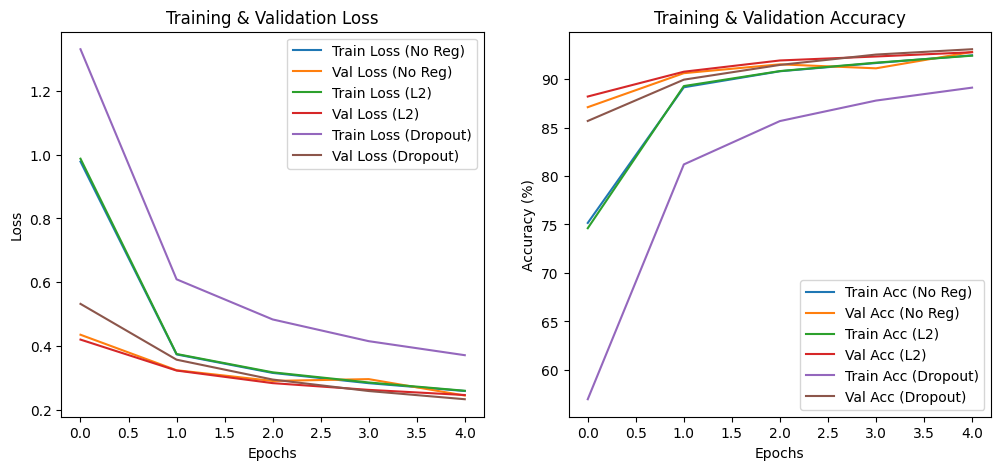

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F

# --------------------
# 1. Data Preparation
# --------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_data = datasets.MNIST(root="./data", train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False)

# --------------------
# 2. Model Definitions
# --------------------
class MLP(nn.Module):
    def __init__(self, dropout=False):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.5) if dropout else nn.Identity()

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# --------------------
# 3. Training Function
# --------------------
def train_and_evaluate(model, optimizer, epochs=5):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(epochs):
        # Training
        model.train()
        correct, total, train_loss = 0, 0, 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            output = model(images)
            loss = F.cross_entropy(output, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(output, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_losses.append(train_loss / len(train_loader))
        train_accs.append(100 * correct / total)

        # Validation
        model.eval()
        correct, total, val_loss = 0, 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                output = model(images)
                loss = F.cross_entropy(output, labels)
                val_loss += loss.item()
                _, predicted = torch.max(output, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_losses.append(val_loss / len(test_loader))
        val_accs.append(100 * correct / total)

        print(f"Epoch {epoch+1}/{epochs} "
              f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.2f}% "
              f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accs[-1]:.2f}%")

    return train_losses, val_losses, train_accs, val_accs

# --------------------
# 4. Experiments
# --------------------
epochs = 5

# (A) No Regularization
model_no_reg = MLP(dropout=False)
optimizer_no_reg = optim.SGD(model_no_reg.parameters(), lr=0.01)
loss_no_reg, val_loss_no_reg, acc_no_reg, val_acc_no_reg = train_and_evaluate(model_no_reg, optimizer_no_reg, epochs)

# (B) L2 Regularization (Weight Decay)
model_l2 = MLP(dropout=False)
optimizer_l2 = optim.SGD(model_l2.parameters(), lr=0.01, weight_decay=1e-4)  # L2 regularization
loss_l2, val_loss_l2, acc_l2, val_acc_l2 = train_and_evaluate(model_l2, optimizer_l2, epochs)

# (C) Dropout
model_dropout = MLP(dropout=True)
optimizer_dropout = optim.SGD(model_dropout.parameters(), lr=0.01)
loss_dropout, val_loss_dropout, acc_dropout, val_acc_dropout = train_and_evaluate(model_dropout, optimizer_dropout, epochs)

# --------------------
# 5. Visualization
# --------------------
plt.figure(figsize=(12,5))

# Loss curves
plt.subplot(1,2,1)
plt.plot(loss_no_reg, label='Train Loss (No Reg)')
plt.plot(val_loss_no_reg, label='Val Loss (No Reg)')
plt.plot(loss_l2, label='Train Loss (L2)')
plt.plot(val_loss_l2, label='Val Loss (L2)')
plt.plot(loss_dropout, label='Train Loss (Dropout)')
plt.plot(val_loss_dropout, label='Val Loss (Dropout)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

# Accuracy curves
plt.subplot(1,2,2)
plt.plot(acc_no_reg, label='Train Acc (No Reg)')
plt.plot(val_acc_no_reg, label='Val Acc (No Reg)')
plt.plot(acc_l2, label='Train Acc (L2)')
plt.plot(val_acc_l2, label='Val Acc (L2)')
plt.plot(acc_dropout, label='Train Acc (Dropout)')
plt.plot(val_acc_dropout, label='Val Acc (Dropout)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training & Validation Accuracy')
plt.legend()

plt.show()


In [ ]:
'''
⭐ 1. DATA PREPARATION
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

✔ transforms.Compose([...])

Creates a pipeline of image transformations.

✔ ToTensor()

Converts image (28×28 pixels) into a PyTorch tensor of shape:

(1, 28, 28)


and scales values from 0–255 → 0–1.

✔ Normalize((0.5,), (0.5,))

Applies:

x_norm = (x - 0.5) / 0.5


This helps neural networks train faster.

train_data = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_data = datasets.MNIST(root="./data", train=False, transform=transform, download=True)


Loads MNIST dataset.

train=True → 60,000 training images

train=False → 10,000 test images

train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False)

✔ DataLoader

Creates mini-batches of size 64.

✔ shuffle=True

Shuffles training data each epoch (GOOD for generalization).

⭐ 2. MODEL DEFINITION
class MLP(nn.Module):
    def __init__(self, dropout=False):
        super(MLP, self).__init__()


Defines a neural network class using PyTorch.

self.fc1 = nn.Linear(784, 256)
self.fc2 = nn.Linear(256, 128)
self.fc3 = nn.Linear(128, 10)

✔ Fully Connected Layers

784 = 28×28 flattened pixels

Layer1: 784 → 256

Layer2: 256 → 128

Output layer: 128 → 10 (digits 0–9)

self.dropout = nn.Dropout(0.5) if dropout else nn.Identity()

✔ Dropout (50% probability)

Turns off half of neurons randomly to prevent overfitting.

If dropout=False, nn.Identity() does nothing.

⭐ FORWARD PASS
def forward(self, x):
    x = x.view(x.size(0), -1)

✔ Flatten image

Converts shape:

(64, 1, 28, 28) → (64, 784)

x = F.relu(self.fc1(x))
x = self.dropout(x)


Apply fully connected layer 1.

Apply ReLU activation.

Apply dropout (or Identity).

x = F.relu(self.fc2(x))
x = self.dropout(x)
x = self.fc3(x)
return x


Final output is raw scores ("logits").

⭐ 3. TRAINING FUNCTION
def train_and_evaluate(model, optimizer, epochs=5):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []


Lists for storing results to plot later.

TRAINING LOOP
for epoch in range(epochs):
    model.train()


model.train() activates dropout and enables gradient updates.

Batch training
for images, labels in train_loader:


Loads 64 images and labels each time.

Forward pass
output = model(images)
loss = F.cross_entropy(output, labels)


Loss = Cross Entropy (Common for classification problems).

Backpropagation
optimizer.zero_grad()
loss.backward()
optimizer.step()


Reset gradients

Compute gradients

Update weights

Accuracy calculation
_, predicted = torch.max(output, 1)
correct += (predicted == labels).sum().item()


torch.max() gives class with highest score.

Compare prediction with true label.

Count correct predictions.

Validation Loop
model.eval()
with torch.no_grad():


Turns OFF dropout

Turns OFF gradient tracking → faster

Similar process as training but without weight updates.

Print after each epoch

Shows:

Train loss

Train accuracy

Validation loss

Validation accuracy

⭐ 4. EXPERIMENTS
A) No Regularization
model_no_reg = MLP(dropout=False)
optimizer_no_reg = optim.SGD(model_no_reg.parameters(), lr=0.01)


Only Neural Network, no regularization.

B) L2 Regularization
optimizer_l2 = optim.SGD(model_l2.parameters(), lr=0.01, weight_decay=1e-4)


L2 REGULARIZATION = weight decay
Penalizes large weights → avoids overfitting.

C) Dropout Regularization
model_dropout = MLP(dropout=True)


Turns ON Dropout layers.

⭐ 5. VISUALIZATION
Loss curves

Shows how training loss and validation loss behave over epochs.

If:

Train loss ↓ but Val loss ↑ → Overfitting

Both ↓ → Good learning

Flat curves → Underfitting

Accuracy curves

Shows model performance.

Understanding the curves:

Big gap: Overfitting

Low accuracy: Underfitting

Smooth rising curve: Good training

🎉 Final Outcome of This Code

This program compares three methods:

Model	Regularization	Effect
No Reg	None	Can overfit
L2 (Weight Decay)	Penalizes large weights	Better generalization
Dropout	Randomly drops neurons	Strong regularization

You can visually see:

Which method gives best accuracy

Which avoids overfitting

Which reduces validation loss